In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../data/processed/securepay_transactions.csv"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (10000, 10)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  10000 non-null  str    
 1   customer_id     10000 non-null  str    
 2   amount          10000 non-null  float64
 3   payment_method  10000 non-null  str    
 4   status          10000 non-null  str    
 5   location        10000 non-null  str    
 6   device          10000 non-null  str    
 7   timestamp       10000 non-null  str    
 8   date            10000 non-null  str    
 9   risk_score      10000 non-null  float64
dtypes: float64(2), str(8)
memory usage: 781.4 KB


In [4]:
df.head(10)

,transaction_id,customer_id,amount,payment_method,status,location,device,timestamp,date,risk_score
0,TXN000001,CUST01127,228096.95,Mobile Money,Successful,Mbarara,Web,2026-01-01 00:00:00,2026-01-01,0.00
1,TXN000002,CUST01460,241267.66,Mobile Money,Successful,Kampala,iPhone,2026-01-01 00:37:00,2026-01-01,0.00
2,TXN000003,CUST00861,379009.39,Bank Transfer,Successful,Gulu,Web,2026-01-01 01:14:01,2026-01-01,0.05
3,TXN000004,CUST01295,141318.22,Bank Transfer,Successful,Kampala,Web,2026-01-01 01:51:02,2026-01-01,0.01
4,TXN000005,CUST01131,159360.79,Mobile Money,Successful,Gulu,Android,2026-01-01 02:28:02,2026-01-01,0.01
5,TXN000006,CUST01096,462358.57,Mobile Money,Suspicious,Gulu,Web,2026-01-01 03:05:03,2026-01-01,1.00
6,TXN000007,CUST01725,28584.04,Bank Transfer,Successful,Gulu,Web,2026-01-01 03:42:04,2026-01-01,0.01
7,TXN000008,CUST01045,243074.33,Mobile Money,Successful,Kampala,Web,2026-01-01 04:19:04,2026-01-01,0.00
8,TXN000009,CUST01639,456444.00,Mobile Money,Suspicious,Mbarara,iPhone,2026-01-01 04:56:05,2026-01-01,1.00
9,TXN000010,CUST00122,305376.32,Bank Transfer,Successful,Jinja,iPhone,2026-01-01 05:33:06,2026-01-01,0.00


In [5]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["date"] = pd.to_datetime(df["date"])

print("Date and timestamp converted successfully!")

print("\nData types:")
print(df[["timestamp", "date"]].dtypes)

Date and timestamp converted successfully!

Data types:
timestamp    datetime64[us]
date         datetime64[us]
dtype: object


In [6]:
df.describe()

,amount,timestamp,date,risk_score
count,10000.000000,10000,10000,10000.000000
mean,248328.701657,2026-05-09 11:59:59.500500,2026-05-09 00:00:08.640000,0.046022
min,526.390000,2026-01-01 00:00:00,2026-01-01 00:00:00,0.000000
25%,123592.762500,2026-03-06 05:59:59.750000,2026-03-06 00:00:00,0.000000
50%,245526.750000,2026-05-09 11:59:59.500000,2026-05-09 00:00:00,0.000000
75%,374344.287500,2026-07-12 17:59:59.250000,2026-07-12 00:00:00,0.000000
max,499902.670000,2026-09-15 00:00:00,2026-09-15 00:00:00,1.000000
std,144036.396603,NaN,NaN,0.198729


In [7]:
status_counts = df["status"].value_counts()

print("Transaction Status:")
print(status_counts)

Transaction Status:
status
Successful    9447
Suspicious     409
Failed         144
Name: count, dtype: int64


In [8]:
status_percentages = (
    df["status"].value_counts(normalize=True) * 100
).round(2)

print("Transaction Status Percentages:")
print(status_percentages)

Transaction Status Percentages:
status
Successful    94.47
Suspicious     4.09
Failed         1.44
Name: proportion, dtype: float64


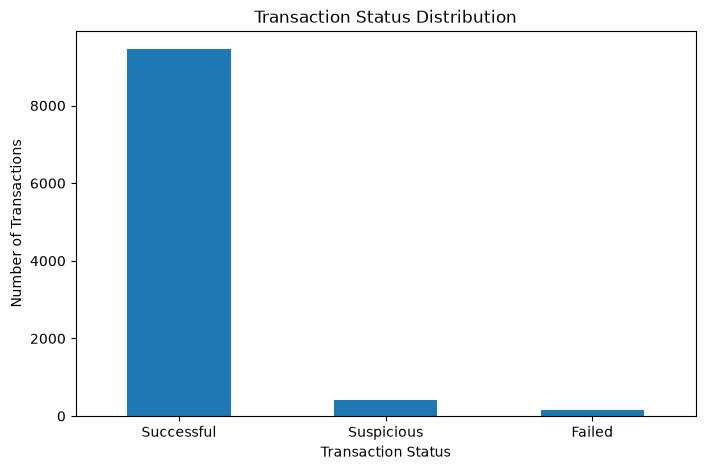

In [9]:
plt.figure(figsize=(8, 5))

df["status"].value_counts().plot(kind="bar")

plt.title("Transaction Status Distribution")
plt.xlabel("Transaction Status")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.show()

In [10]:
amount_by_status = df.groupby("status")["amount"].agg(
    ["count", "mean", "min", "max"]
).round(2)

print("Transaction Amount by Status:")
amount_by_status

Transaction Amount by Status:


,count,mean,min,max
status,,,,
Failed,144,235102.50,3312.84,499135.35
Successful,9447,239765.00,526.39,499902.67
Suspicious,409,450788.12,401056.02,499667.89


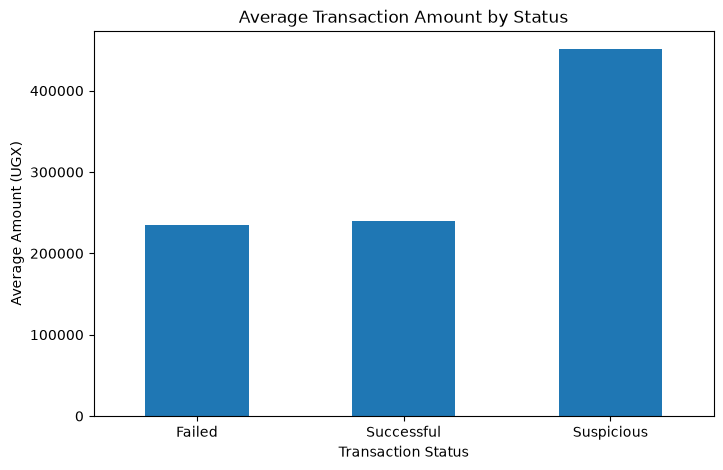

In [11]:
plt.figure(figsize=(8, 5))

df.groupby("status")["amount"].mean().plot(kind="bar")

plt.title("Average Transaction Amount by Status")
plt.xlabel("Transaction Status")
plt.ylabel("Average Amount (UGX)")
plt.xticks(rotation=0)

plt.show()

In [12]:
payment_method_counts = df["payment_method"].value_counts()

print("Transactions by Payment Method:")
print(payment_method_counts)

Transactions by Payment Method:
payment_method
Mobile Money     3363
Bank Transfer    3322
Card             3315
Name: count, dtype: int64


In [13]:
payment_status = pd.crosstab(
    df["payment_method"],
    df["status"]
)

print("Payment Method vs Transaction Status:")
payment_status

Payment Method vs Transaction Status:


status,Failed,Successful,Suspicious
payment_method,,,
Bank Transfer,54,3123,145
Card,40,3132,143
Mobile Money,50,3192,121


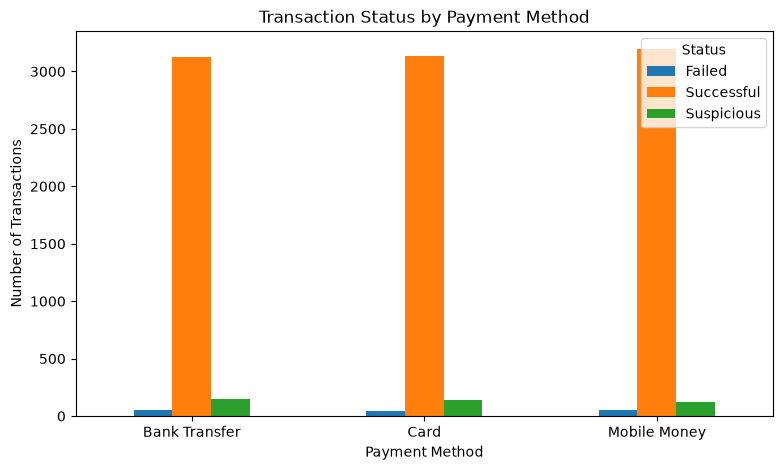

In [14]:
payment_status.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Transaction Status by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.legend(title="Status")
plt.show()

In [15]:
payment_status_percentages = pd.crosstab(
    df["payment_method"],
    df["status"],
    normalize="index"
) * 100

payment_status_percentages = payment_status_percentages.round(2)

print("Status Percentages by Payment Method:")
payment_status_percentages

Status Percentages by Payment Method:


status,Failed,Successful,Suspicious
payment_method,,,
Bank Transfer,1.63,94.01,4.36
Card,1.21,94.48,4.31
Mobile Money,1.49,94.92,3.60


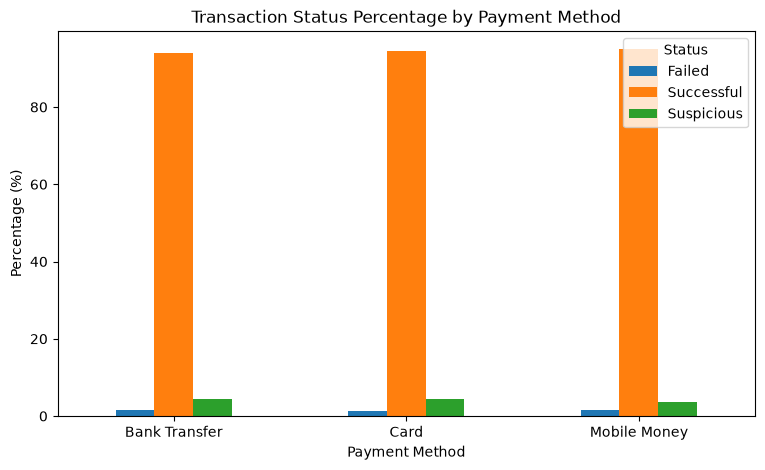

In [16]:
payment_status_percentages.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Transaction Status Percentage by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.legend(title="Status")
plt.show()

In [17]:
location_counts = df["location"].value_counts()

print("Transactions by Location:")
print(location_counts)

Transactions by Location:
location
Mbale      2095
Mbarara    2027
Gulu       1975
Jinja      1960
Kampala    1943
Name: count, dtype: int64


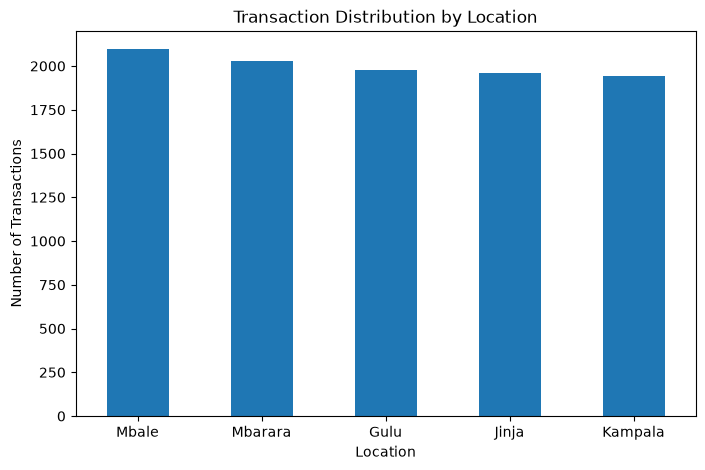

In [18]:
plt.figure(figsize=(8, 5))

location_counts.plot(kind="bar")

plt.title("Transaction Distribution by Location")
plt.xlabel("Location")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.show()

In [19]:
location_status = pd.crosstab(
    df["location"],
    df["status"]
)

print("Location vs Transaction Status:")
location_status

Location vs Transaction Status:


status,Failed,Successful,Suspicious
location,,,
Gulu,33,1867,75
Jinja,37,1848,75
Kampala,23,1831,89
Mbale,31,1978,86
Mbarara,20,1923,84


In [20]:
location_status_percentages = pd.crosstab(
    df["location"],
    df["status"],
    normalize="index"
) * 100

location_status_percentages = location_status_percentages.round(2)

print("Status Percentages by Location:")
location_status_percentages

Status Percentages by Location:


status,Failed,Successful,Suspicious
location,,,
Gulu,1.67,94.53,3.80
Jinja,1.89,94.29,3.83
Kampala,1.18,94.24,4.58
Mbale,1.48,94.42,4.11
Mbarara,0.99,94.87,4.14


In [21]:
location_status_percentages = pd.crosstab(
    df["location"],
    df["status"],
    normalize="index"
) * 100

location_status_percentages = location_status_percentages.round(2)

print("Status Percentages by Location:")
location_status_percentages

Status Percentages by Location:


status,Failed,Successful,Suspicious
location,,,
Gulu,1.67,94.53,3.80
Jinja,1.89,94.29,3.83
Kampala,1.18,94.24,4.58
Mbale,1.48,94.42,4.11
Mbarara,0.99,94.87,4.14


In [22]:
device_counts = df["device"].value_counts()

print("Transactions by Device:")
print(device_counts)

Transactions by Device:
device
iPhone     3442
Web        3327
Android    3231
Name: count, dtype: int64


In [23]:
device_status = pd.crosstab(
    df["device"],
    df["status"]
)

print("Device vs Transaction Status:")
device_status

Device vs Transaction Status:


status,Failed,Successful,Suspicious
device,,,
Android,40,3047,144
Web,57,3141,129
iPhone,47,3259,136


In [24]:
risk_by_status = df.groupby("status")["risk_score"].agg(
    ["count", "mean", "min", "max"]
).round(4)

print("Risk Score Analysis by Transaction Status:")
risk_by_status

Risk Score Analysis by Transaction Status:


,count,mean,min,max
status,,,,
Failed,144,0.1142,0.00,1.00
Successful,9447,0.0042,0.00,0.26
Suspicious,409,0.9884,0.83,1.00


In [25]:
df["hour"] = df["timestamp"].dt.hour

hourly_transactions = df["hour"].value_counts().sort_index()

print("Transactions by Hour:")
print(hourly_transactions)

Transactions by Hour:
hour
0     418
1     417
2     416
3     417
4     417
5     416
6     417
7     416
8     417
9     417
10    416
11    417
12    417
13    416
14    417
15    416
16    417
17    417
18    416
19    417
20    417
21    416
22    417
23    416
Name: count, dtype: int64


In [26]:
total_value = df["amount"].sum()

print(f"Total Transaction Value: UGX {total_value:,.2f}")

Total Transaction Value: UGX 2,483,287,016.57


In [27]:
unique_customers = df["customer_id"].nunique()

print(f"Unique Customers: {unique_customers}")

Unique Customers: 1987
